# First Steps Towards Stochastic Expectation-Maximization

In this notebook, I'll describe and demonstrate an early version of *stochastic expectation maximization* (SEM), a technique that I learned about primarily from [this paper](https://proceedings.neurips.cc/paper_files/paper/2018/hash/aba22f748b1a6dff75bda4fd1ee9fe07-Abstract.html). This framework applies when the joint distribution between latent and observed variables is in an exponential family, which is indeed true in our case. 

### SEM

I implemented the calculation of the basic SEM update. This update consists in performing an EM-like parameter update using a *single* edge and modifying the current estimate accordingly. Suppose that we have a current estimate $\hat{\theta}^{(t)}$ at time $t$, and that in step $t+1$ we get an update $\theta'$. Then, the basic new estimate in the SEM framework is 

$$
\hat{\theta}^{(t+1)}  = (1-\rho^{(t)})\hat{\theta}^{(t)} + \rho^{(t)}\theta'. 
$$

We can think of $\rho^{(t)}$ as a learning rate that tunes how quickly the parameter update occurs. As in other optimization frameworks, it is possible to choose $\rho^{(t)}$ to decrease over time. In the cited paper above, the authors instead take a different approach in which they modify the update in order to make it unnecessary to tune the learning rate. 

### *What I Did*

I implemented the *simplest* version of SEM. In this version, we first sample an edge $e$. From $e$, we then compute a vector of *expected sufficient statistics* with respect to the distribution over possible edges that could have generated $e$. These expectations summarize the important features of the data. From these expectations, it is then possible to form the update $\theta'$, after which we can iterate the equation above until (hopefully) convergence. 

The approach I used involves an approximation: we approximate that the number of nodes added from the remainder of the hypergraph is Poisson with expectation $\gamma$, rather than binomial with parameter $\gamma/N$. This *should* be ok when $N$ is large. Because the algorithm doesn't seem to be working perfectly, this is one thing that we might want to take another look at later. 

### *Findings*

So far, what I've found is that *this works sometimes*. In particular, there are settings of the parameters where this algorithm performs very well, in practical time, on large hypergraphs. Here's an example of estimating the parameters on a hypergraph with 1M edges and roughly 1M nodes. 

In [58]:
%load_ext autoreload
%autoreload 2

import importlib 
m = importlib.import_module(".model", "src")
sem = importlib.import_module(".sem", "src") # my implementation of baby SEM
em = importlib.import_module(".em", "src")
ll = importlib.import_module(".likelihoods", "src")
from matplotlib import pyplot as plt
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
# generate some sample data

eta   = 0.7   # node retention in edges
beta  = 1.2   # poisson number of novel nodes
gamma = 0.8   # poisson number of nodes from graph

timesteps = int(1e4)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

This hypergraph has 10002 edges and 11910 nodes.


In [60]:
# initialize a model with 
# initial parameter guesses

init_pars = {"eta"   : 0.3, 
                        "beta"  : 0.4, 
                        "gamma" : 0.02}
EM = sem.SEM(H, 
             ll.guaranteed_edge_sample_likelihood,
             ll.nodes_from_hypergraph_likelihood,
             ll.novel_nodes_likelihood,
             pars = init_pars, 
             memoize = True)

In [61]:
# track the parameter estimates over time
ETA   = []
BETA  = []
GAMMA = []
steps = 5000

# main loop
for i in range(steps):

    if i % 250 == 0:
        print("--------")
        print(f"Completed step {i}")
        print(EM.pars)
        
        
    EM.SEM_step(0.002) # both the stochastic E and the M steps are in here
    ETA.append(EM.pars["eta"])
    BETA.append(EM.pars["beta"])
    GAMMA.append(EM.pars["gamma"])

--------
Completed step 0
{'eta': 0.3, 'beta': 0.4, 'gamma': 0.02}
--------
Completed step 250
{'eta': 0.4440173956323363, 'beta': 0.6995034560943676, 'gamma': 0.33251439797027815}
--------
Completed step 500
{'eta': 0.5324119949968295, 'beta': 0.8762236518182865, 'gamma': 0.5106883356218385}
--------
Completed step 750
{'eta': 0.5799826891857764, 'beta': 0.9705249586728387, 'gamma': 0.6090029487358622}
--------
Completed step 1000
{'eta': 0.6218325180424271, 'beta': 1.073990159158361, 'gamma': 0.7051832949326042}
--------
Completed step 1250
{'eta': 0.6440972861775129, 'beta': 1.1406552964259118, 'gamma': 0.7937079156731497}
--------
Completed step 1500
{'eta': 0.6574317890625192, 'beta': 1.1829976986773596, 'gamma': 0.804127063986303}
--------
Completed step 1750
{'eta': 0.6672052352770094, 'beta': 1.1733589215680098, 'gamma': 0.8143816090102544}
--------
Completed step 2000
{'eta': 0.6668759837482485, 'beta': 1.205822065874136, 'gamma': 0.8280828226758239}
--------
Completed step 22

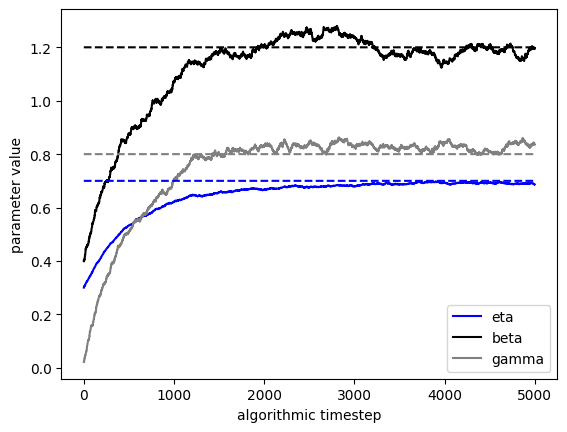

In [62]:
# how'd we do?     
T = np.arange(steps)
plt.plot(T, ETA,   label = "eta", color = "blue")
plt.plot(T, BETA,  label = "beta", color = "black")
plt.plot(T, GAMMA, label = "gamma", color = "grey")

plt.plot(T, np.ones((steps,))*eta, color = "blue", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*beta, color = "black", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*gamma, color = "grey", linestyle = "dashed")

plt.gca().set(xlabel = "algorithmic timestep", ylabel = "parameter value")
plt.legend()

That looks pretty promising! 

## A Less Successful Example 

On the other hand, I have also observed cases, especially when the parameters are small, with less good performance. Here's a smaller example: 

In [63]:
# generate some sample data

eta   = 0.6   # node retention in edges
beta  = 0.3   # poisson number of novel nodes
gamma = 0.2   # poisson number of nodes from graph

timesteps = int(10000)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")



This hypergraph has 10002 edges and 3019 nodes.


--------
Completed step 0
{'eta': 0.672144098222016, 'beta': 1.1013262566365116, 'gamma': 0.7824819730464482}
--------
Completed step 5
{'eta': 0.6465015859709495, 'beta': 0.7449051412812938, 'gamma': 0.5576670722504068}
--------
Completed step 10
{'eta': 0.6252143384359115, 'beta': 0.5675182368751914, 'gamma': 0.40611725344547706}
--------
Completed step 15
{'eta': 0.6381733115212292, 'beta': 0.45762484369243195, 'gamma': 0.3115542172121993}
--------
Completed step 20
{'eta': 0.61714118011835, 'beta': 0.4089472939519442, 'gamma': 0.2690194787839285}
--------
Completed step 25
{'eta': 0.6152412946442921, 'beta': 0.3806198876056835, 'gamma': 0.2475197983410199}
--------
Completed step 30
{'eta': 0.6133111540195879, 'beta': 0.3629972374322801, 'gamma': 0.21282578337197927}
--------
Completed step 35
{'eta': 0.6033762634338002, 'beta': 0.3067268387313872, 'gamma': 0.2359846902421571}
--------
Completed step 40
{'eta': 0.5855620047589433, 'beta': 0.330148931002497, 'gamma': 0.2144059530938

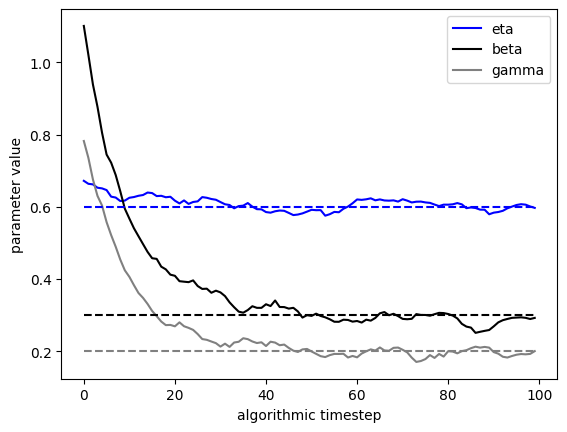

In [64]:
# initialize a model with 
# initial parameter guesses
EM = sem.SEM(H, 
             ll.guaranteed_edge_sample_likelihood,
             ll.nodes_from_hypergraph_likelihood,
             ll.novel_nodes_likelihood,
             pars = init_pars, memoize = True)

# track the parameter estimates over time
ETA   = []
BETA  = []
GAMMA = []

total = 5000
batch_size = 50
steps = int(total / batch_size)

for i in range(steps):

    EM.SEM_step(0.002*batch_size, min_time=0, batch_size = batch_size) # both the stochastic E and the M steps are in here
    if i % int(steps/20) == 0:
        print("--------")
        print(f"Completed step {i}")
        print(EM.pars)
    ETA.append(EM.pars["eta"])
    BETA.append(EM.pars["beta"])
    GAMMA.append(EM.pars["gamma"])
    
# how'd we do?     
T = np.arange(steps)
plt.plot(T, ETA,   label = "eta", color = "blue")
plt.plot(T, BETA,  label = "beta", color = "black")
plt.plot(T, GAMMA, label = "gamma", color = "grey")

plt.plot(T, np.ones((steps,))*eta, color = "blue", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*beta, color = "black", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*gamma, color = "grey", linestyle = "dashed")

plt.gca().set(xlabel = "algorithmic timestep", ylabel = "parameter value")
plt.legend()